downloaded: cosmon_c103_r005-8_dineutron_Swave.hdf5
Sector: PSQ0_A1g
N_samples= 1490  N_op= 6  Nt= 26
condition number xi_cn= 1.8182886844109027
post-rotation Hermiticity violation on mean: 0.0
ROT0 plateau value: 1.430475488321902 +/- 0.00027075445141919624

Sector: PSQ1_A1
N_samples= 1490  N_op= 10  Nt= 26
condition number xi_cn= 1.6004704155897485
post-rotation Hermiticity violation on mean: 0.0
ROT0 plateau value: 1.4419275913596084 +/- 0.00027388229767728883

Sector: PSQ2_A1
N_samples= 1490  N_op= 21  Nt= 26
condition number xi_cn= 1.592100196730859
post-rotation Hermiticity violation on mean: 0.0
ROT0 plateau value: 1.4535399743125201 +/- 0.00026485077033712174

Sector: PSQ3_A1
N_samples= 1490  N_op= 9  Nt= 26
condition number xi_cn= 1.2796913364222755
post-rotation Hermiticity violation on mean: 0.0
ROT0 plateau value: 1.46505693521995 +/- 0.0002664626513160396

Sector: PSQ4_A1
N_samples= 1490  N_op= 10  Nt= 26
condition number xi_cn= 1.585314862479403
post-rotation Hermiticity 

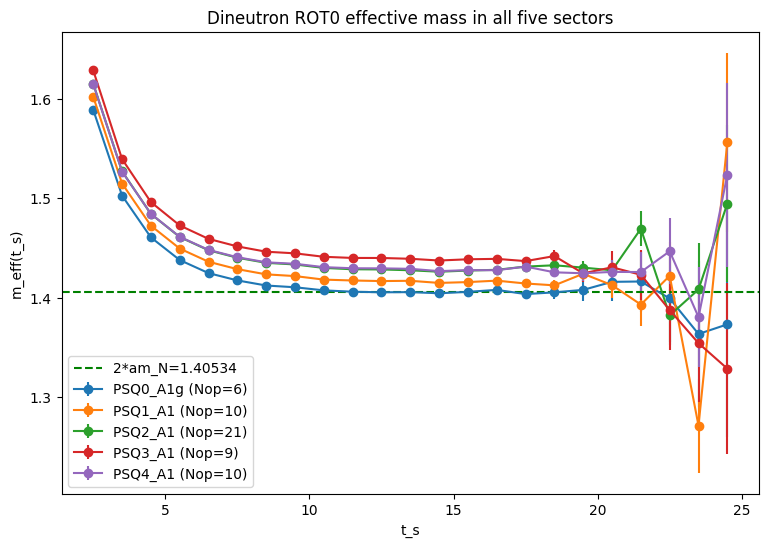

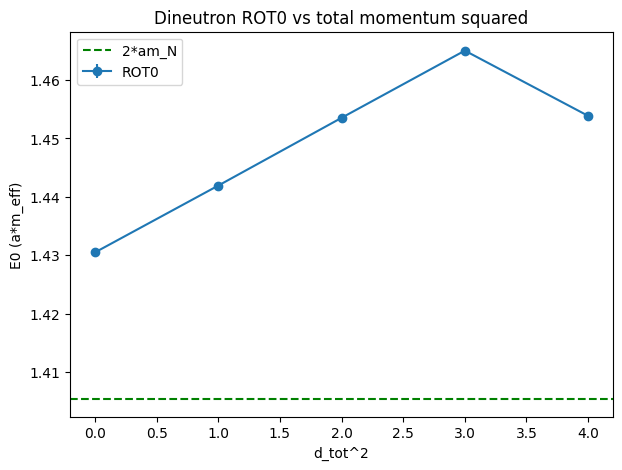

Summary: ROT0 plateau values
sector      Nop     cond           E0       E0_err
PSQ0_A1g      6    1.818     1.430475     0.000271
PSQ1_A1      10    1.600     1.441928     0.000274
PSQ2_A1      21    1.592     1.453540     0.000265
PSQ3_A1       9    1.280     1.465057     0.000266
PSQ4_A1      10    1.585     1.453877     0.000275


In [ ]:
# dineutron: single-pivot gevp analysis across all five sectors
# physics references:
# thesis:
# 4.2:  correlation function c_ij(t)=um_n (z_i^(n) * z_j^(n)* * e^{-e_n * t})
#  4.4:  effective mass meff(t)=ln( c(t) / c(t + 1) )
#  4.6:  ordered eigenvalues lambda0 >= lambda1 >= ...
#  4.9:  generalized eigenvalue problem c(td) * v_n=lambda_n * c(t0) * v_n
#  4.10: rotated correlator d_ll(t) ~ |z'|^2 * e^{-e_l * t}
#  4.12: condition number xicn=lambdamax / lambdamin
#  sec 4.2:   solve gevp on the mean data set, then apply the fixed pivot to bootstrap samples
#  sec. 4.2.1: single-pivot method requiring td >= 2 * t0
#  paper eq. 2.1–2.4: correlator setup, gevp diagonalization, rotation matrix, and rotated correlator
#  paper sec. ii.c: chosen parameters t0=5 and td=10
#  paper table i:    dineutron a1g operator basis counts: nop=6, 10, 21, 9, 10
#  paper eq 2.15: nucleon mass a * mn=0.70267(40), giving a two-nucleon threshold 2 * a * mn=1.40534
import urllib.request

url = "https://portal.nersc.gov/cfs/m2986/cosmon/nn_c103_2505.05547/cosmon_c103_r005-8_dineutron_Swave.hdf5"
file_path = "cosmon_c103_r005-8_dineutron_Swave.hdf5"

urllib.request.urlretrieve(url, file_path)
print("downloaded:", file_path)
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import eigh
file_path="cosmon_c103_r005-8_dineutron_Swave.hdf5"
groups=["PSQ0_A1g", "PSQ1_A1", "PSQ2_A1", "PSQ3_A1", "PSQ4_A1"]
# GEVP parameters
t0=5
td=10
t_start=2
N_boot=1000
rng=np.random.default_rng(12345)
def symmetrize_single(C):
    #  Symmetrizes the correlator tensor of shape (nOp, nOp, nTime) to enforce exact hermicity
    return 0.5*(C+np.conj(np.transpose(C,(1,0,2))))

def meff_from_diag(diag_correlator, t_start=2):
    # calculates effective mass with half integer time slices using sarah eq 4.4
    correlator = diag_correlator.real
    num_times = diag_correlator.shape[0]
    time_indices = np.arange(t_start, num_times - 1)
    half_time_slices = time_indices + 0.5
    current_correlator = correlator[t_start:-1]
    next_correlator = correlator[t_start + 1:]
    with np.errstate(divide="ignore", invalid="ignore"):
        ratio = current_correlator / next_correlator
        ratio = np.where(ratio > 0, ratio, np.nan)
        effective_mass = np.log(ratio)
    return half_time_slices, effective_mass
# storage
results={}

# Main loop over the five dineutron sectors
for g in groups:
    print("Sector:", g)
    with h5py.File(file_path, "r") as f:
        data=f[g]["data"][:] # (1490, N_op, N_op, 26)
    N_samples, N_op, _, Nt=data.shape
    print("N_samples=", N_samples, " N_op=", N_op, " Nt=", Nt)

    # mean and symmetrize
    C_mean=data.mean(axis=0)
    C_sym =symmetrize_single(C_mean)

    # solve GEVP on the mean
    C_t0=C_sym[:, :, t0]
    C_td=C_sym[:, :, td]
    evals, evecs=eigh(C_td, C_t0)

    # order eigenvalues descending
    idx=np.argsort(evals)[::-1]
    evals=evals[idx]
    evecs=evecs[:, idx]

    # normalize V^dagger C(t0) V=I
    gram=evecs.conj().T @ C_t0 @ evecs
    scale=np.sqrt(np.abs(np.diag(gram)))
    V=evecs / scale[np.newaxis, :]

    # condition number
    cond=np.max(np.abs(evals)) / np.min(np.abs(evals))
    print("condition number xi_cn=", cond)

    # rotate C(t) with the fixed pivot
    D_mean=np.zeros((N_op, N_op, Nt), dtype=complex)
    for it in range(Nt):
        D_mean[:, :, it]=V.conj().T @ C_sym[:, :, it] @ V
        # Post rotation hermicity test D(t) should be hermetian or else we force it
        D_mean[:, :, it] = 0.5 * (D_mean[:, :, it] + D_mean[:, :, it].conj().T)
    max_violation = 0.0
    for it in range(Nt):
        D_it = D_mean[:, :, it]
        v = np.max(np.abs(D_it - D_it.conj().T))
        max_violation = max(max_violation, v)
    print("post-rotation Hermiticity violation on mean:", max_violation)
    # effective masses from the diagonal
    t_s, _=meff_from_diag(D_mean[0, 0, :], t_start=t_start)
    n_t=len(t_s)
    n_modes=min(3, N_op)

    # bootstrap with fixed pivot
    meff_boot=np.full((N_boot, n_modes, n_t), np.nan, dtype=float)
    for b in range(N_boot):
        idx_b=rng.integers(0, N_samples, size=N_samples)
        C_b=symmetrize_single(data[idx_b].mean(axis=0))

        D_b=np.zeros((N_op, N_op, Nt), dtype=complex)
        for it in range(Nt):
            D_b[:, :, it]=V.conj().T @ C_b[:, :, it] @ V
            D_b[:, :, it] = 0.5 * (D_b[:, :, it] + D_b[:, :, it].conj().T)

        for l in range(n_modes):
            _, meff_l=meff_from_diag(D_b[l, l, :], t_start=t_start)
            meff_boot[b, l, :]=meff_l

    # mean and std over bootstrap
    meff_mean=np.nanmean(meff_boot, axis=0)
    meff_std =np.nanstd(meff_boot, axis=0)

    # store
    results[g]=dict(
        N_op=N_op, cond=cond, evals=evals, V=V,
        D_mean=D_mean, t_s=t_s,
        meff_mean=meff_mean, meff_std=meff_std,
        meff_boot=meff_boot,
    )

    # plateau estimate for ROT0
    mask=(t_s >= 4.5) & (t_s <= 8.5)
    E0_boot=np.nanmean(meff_boot[:, 0, :][:, mask], axis=1)
    E0=np.nanmean(E0_boot)
    E0_err=np.nanstd(E0_boot)
    print("ROT0 plateau value:", E0, "+/-", E0_err)
    print()

# Plots
# Plot 1: ROT0 vs t_s for all 5 sectors
plt.figure(figsize=(9, 6))
for g in groups:
    r=results[g]
    plt.errorbar(r["t_s"], r["meff_mean"][0], yerr=r["meff_std"][0],fmt="o-", label=f"{g} (Nop={r['N_op']})")
plt.axhline(2 * 0.70267, color="green", linestyle="--",label="2*am_N=1.40534")
plt.xlabel("t_s")
plt.ylabel("m_eff(t_s)")
plt.title("Dineutron ROT0 effective mass in all five sectors")
plt.legend()
plt.savefig("dineutron_rot0_all_sectors.png", dpi=150, bbox_inches="tight")
plt.show()

# Plot 2: ROT0 plateau vs d_tot^2
d2=np.array([0, 1, 2, 3, 4])
E0_vals, E0_errs=[], []
for g in groups:
    r=results[g]
    mask=(r["t_s"] >= 4.5) & (r["t_s"] <= 8.5)
    E0_boot=np.nanmean(r["meff_boot"][:, 0, :][:, mask], axis=1)
    E0_vals.append(np.nanmean(E0_boot))
    E0_errs.append(np.nanstd(E0_boot))
E0_vals=np.array(E0_vals)
E0_errs=np.array(E0_errs)

plt.figure(figsize=(7, 5))
plt.errorbar(d2, E0_vals, yerr=E0_errs, fmt="o-", label="ROT0")
plt.axhline(2 * 0.70267, color="green", linestyle="--", label="2*am_N")
plt.xlabel("d_tot^2")
plt.ylabel("E0 (a*m_eff)")
plt.title("Dineutron ROT0 vs total momentum squared")
plt.legend()
plt.savefig("dineutron_rot0_vs_d2.png", dpi=150, bbox_inches="tight")
plt.show()

# summary table
print("Summary: ROT0 plateau values")
print(f"{'sector':10s} {'Nop':>4s} {'cond':>8s} {'E0':>12s} {'E0_err':>12s}")
for g in groups:
    r=results[g]
    mask=(r["t_s"] >= 4.5) & (r["t_s"] <= 8.5)
    E0_boot=np.nanmean(r["meff_boot"][:, 0, :][:, mask], axis=1)
    E0=np.nanmean(E0_boot)
    E0_err=np.nanstd(E0_boot)
    print(f"{g:10s} {r['N_op']:>4d} {r['cond']:>8.3f} {E0:>12.6f} {E0_err:>12.6f}")

group= PSQ0_A1g
N_samples= 1490  N_op= 6  Nt= 26

Scan A: td= 10  fixed, t0 varied
  t0=3, td=10: E0=1.430475 +/- 0.000271, cond=2.332
  t0=4, td=10: E0=1.430475 +/- 0.000271, cond=2.055
  t0=5, td=10: E0=1.430475 +/- 0.000271, cond=1.818
  t0=6, td=10: E0=1.430477 +/- 0.000271, cond=1.612
  t0=7, td=10: E0=1.430479 +/- 0.000271, cond=1.430
  t0=8, td=10: E0=1.430482 +/- 0.000271, cond=1.270
Scan B: t0= 5  fixed, td varied
  t0=5, td=8: E0=1.430475 +/- 0.000271, cond=1.432
  t0=5, td=9: E0=1.430475 +/- 0.000271, cond=1.613
  t0=5, td=10: E0=1.430475 +/- 0.000271, cond=1.818
  t0=5, td=11: E0=1.430477 +/- 0.000271, cond=2.048
  t0=5, td=12: E0=1.430479 +/- 0.000271, cond=2.304
  t0=5, td=13: E0=1.430481 +/- 0.000271, cond=2.598


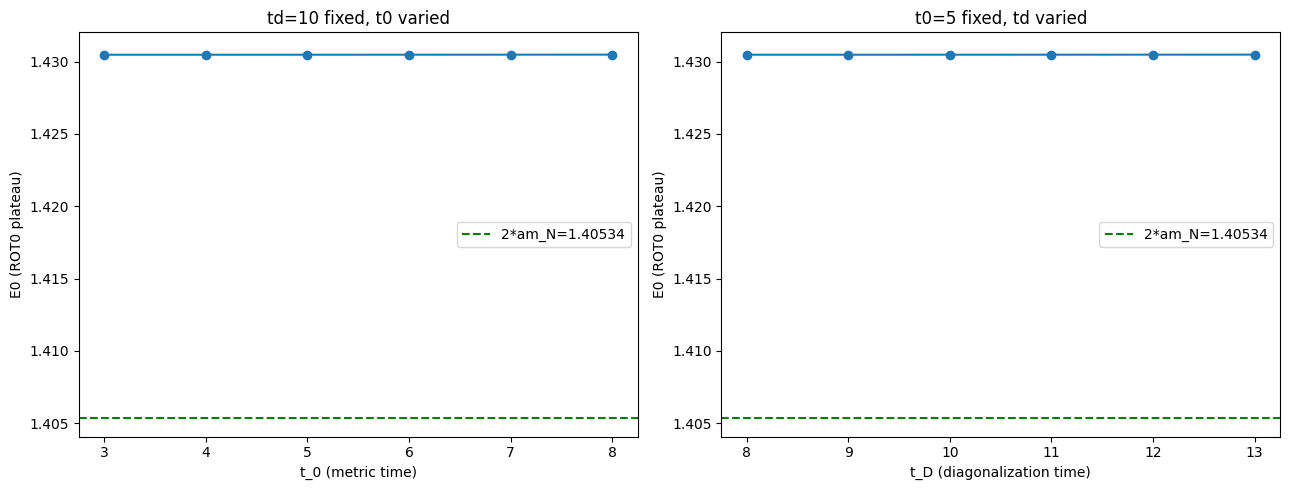

post-rotation Hermiticity violation: 0.0

Single-exp fit to D_00(t) over t in [4, 10]:
  A =1253.428984   (normalization artifact, not physics)
  E0=1.425492 +/- 0.000275


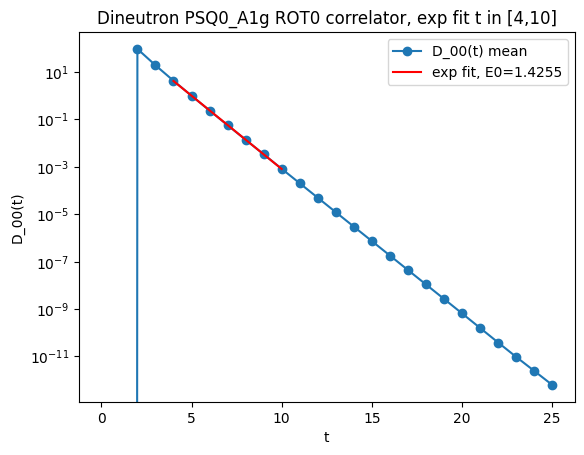


Constant fit to m_eff(t_s) over t_s in [4.5, 10.5]:
E0=1.424267 +/- 0.000279


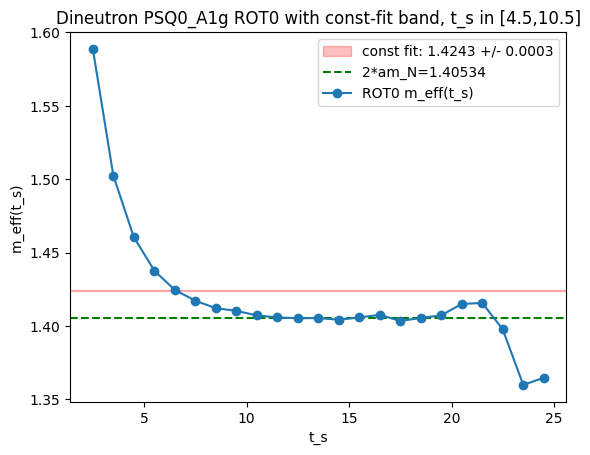


Summary for PSQ0_A1g:
  Single-exp fit E0 (t in [4,10])=1.425492 +/- 0.000275
  Constant fit E0 (t_s in [4.5,10.5]) =1.424267 +/- 0.000279
  2*am_N=1.405340


In [ ]:
# dineutron: GEVP stability scan and single-exp and constant fits
# physics references:
# thesis:
#  4.4:  effective mass meff(t)=ln( c(t) / c(t + 1) )
#  4.6:  ordered eigenvalues lambda0 >= lambda1 >= ...
#  4.9:  generalized eigenvalue problem c(td) * v_n=lambda_n * c(t0) * v_n
#  4.10: rotated correlator d_ll(t) ~ |z'|^2 * e^{-e_l * t}
#  4.12: condition number xicn=lambdamax / lambdamin
#  sec 4.2:   solve gevp on the mean data set, then apply the fixed pivot to bootstrap samples
#  sec. 4.2.1: single-pivot method requiring td >= 2 * t0
#  paper eq. 2.1–2.4: correlator setup, gevp diagonalization, rotation matrix, and rotated correlator
#  paper sec. ii.c: chosen parameters t0=5 and td=10
#  paper eq 2.15: nucleon mass a * mn=0.70267(40), giving a two-nucleon threshold 2 * a * mn=1.40534

import h5py
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import eigh

# ---- load PSQ0_A1g ----
file_path="cosmon_c103_r005-8_dineutron_Swave.hdf5"
group="PSQ0_A1g"

with h5py.File(file_path, "r") as f:
    data=f[group]["data"][:]     # (1490, 6, 6, 26)

N_samples, N_op, _, Nt=data.shape
print("group=", group)
print("N_samples=", N_samples, " N_op=", N_op, " Nt=", Nt)
print()

def symmetrize_single(C):
    return 0.5 * (C + np.conj(np.transpose(C, (1, 0, 2))))
def meff_from_diag(diag_correlator, t_start=2):
    # calculates effective mass with half integer time slices using sarah eq 4.4
    correlator = diag_correlator.real
    num_times = diag_correlator.shape[0]
    time_indices = np.arange(t_start, num_times - 1)
    half_time_slices = time_indices + 0.5
    current_correlator = correlator[t_start:-1]
    next_correlator = correlator[t_start + 1:]
    with np.errstate(divide="ignore", invalid="ignore"):
        ratio = current_correlator / next_correlator
        ratio = np.where(ratio > 0, ratio, np.nan)
        effective_mass = np.log(ratio)
    return half_time_slices, effective_mass

def single_pivot_gevp(C_sym, t0, td):
    C_t0=C_sym[:, :, t0]
    C_td=C_sym[:, :, td]
    evals, evecs=eigh(C_td, C_t0)
    idx=np.argsort(evals)[::-1]
    evals=evals[idx]
    evecs=evecs[:, idx]
    gram=evecs.conj().T @ C_t0 @ evecs
    scale=np.sqrt(np.abs(np.diag(gram)))
    V=evecs / scale[np.newaxis, :]
    return evals, V

def rotate_all(C_sym, V):
    N_op_local=C_sym.shape[0]
    Nt_local=C_sym.shape[2]
    D=np.zeros((N_op_local, N_op_local, Nt_local), dtype=complex)
    for it in range(Nt_local):
        D[:, :, it]=V.conj().T @ C_sym[:, :, it] @ V
        D[:, :, it] = 0.5 * (D[:, :, it] + D[:, :, it].conj().T)
    return D

def bootstrap_E0_rot0(data, t0, td, t_lo, t_hi,nboot=1000, seed=12345, t_start=2):
    rng=np.random.default_rng(seed)
    C_mean=data.mean(axis=0)
    C_sym =symmetrize_single(C_mean)
    evals, V=single_pivot_gevp(C_sym, t0, td)

    E0_boot=np.full(nboot, np.nan)
    for b in range(nboot):
        idx=rng.integers(0, N_samples, size=N_samples)
        C_b=symmetrize_single(data[idx].mean(axis=0))
        D_b=rotate_all(C_b, V)
        ts_b, m_b=meff_from_diag(D_b[0, 0, :], t_start=t_start)
        mask=(ts_b >= t_lo) & (ts_b <= t_hi)
        E0_boot[b]=np.nanmean(m_b[mask])
    return np.nanmean(E0_boot), np.nanstd(E0_boot), evals

# Part 1: stability scan
t_lo_win=4.5
t_hi_win=8.5
# Scan one fix td=10,vary t0
td_fixed=10
t0_scan=[3, 4, 5, 6, 7, 8]

print("Scan A: td=", td_fixed, " fixed, t0 varied")
E0_vs_t0, E0err_vs_t0, cond_vs_t0=[], [], []
for t0 in t0_scan:
    E0, Eerr, evals=bootstrap_E0_rot0(data, t0, td_fixed, t_lo_win, t_hi_win)
    cond=np.max(np.abs(evals)) / np.min(np.abs(evals))
    E0_vs_t0.append(E0); E0err_vs_t0.append(Eerr); cond_vs_t0.append(cond)
    print(f"  t0={t0}, td={td_fixed}: E0={E0:.6f} +/- {Eerr:.6f}, cond={cond:.3f}")

# Scan second fix t0=5, vary td
t0_fixed=5
td_scan=[8, 9, 10, 11, 12, 13]

print("Scan B: t0=", t0_fixed, " fixed, td varied")
E0_vs_td, E0err_vs_td, cond_vs_td=[], [], []
for td in td_scan:
    E0, Eerr, evals=bootstrap_E0_rot0(data, t0_fixed, td, t_lo_win, t_hi_win)
    cond=np.max(np.abs(evals)) / np.min(np.abs(evals))
    E0_vs_td.append(E0); E0err_vs_td.append(Eerr); cond_vs_td.append(cond)
    print(f"  t0={t0_fixed}, td={td}: E0={E0:.6f} +/- {Eerr:.6f}, cond={cond:.3f}")

fig, axes=plt.subplots(1, 2, figsize=(13, 5))
axes[0].errorbar(t0_scan, E0_vs_t0, yerr=E0err_vs_t0, fmt="o-")
axes[0].axhline(2 * 0.70267, color="green", linestyle="--",label="2*am_N=1.40534")
axes[0].set_xlabel("t_0 (metric time)")
axes[0].set_ylabel("E0 (ROT0 plateau)")
axes[0].set_title(f"td={td_fixed} fixed, t0 varied")
axes[0].legend()

axes[1].errorbar(td_scan, E0_vs_td, yerr=E0err_vs_td, fmt="o-")
axes[1].axhline(2 * 0.70267, color="green", linestyle="--",label="2*am_N=1.40534")
axes[1].set_xlabel("t_D (diagonalization time)")
axes[1].set_ylabel("E0 (ROT0 plateau)")
axes[1].set_title(f"t0={t0_fixed} fixed, td varied")
axes[1].legend()

plt.tight_layout()
plt.savefig("dineutron_stability_scan.png", dpi=150, bbox_inches="tight")
plt.show()

# LINEAR fit to ln D_00
# note on amplitude:
# using gevp normalization where v_dagger * c(t0) * v = i and t0 = 5
# the rotated correlator d00(t0) equals 1 exactly
#   if we fit d00(t) = a * exp(-e * t) without including t0
#   the fitted a is just the value at t = 0: a = exp(t0 * e0) ~ 1250 for e0 ~ 1.43
#   this amplitude a is just math setup stuff not real physics
#   the real physics is in e0
#
# we fit ln(d00(t)) = ln(a) - e * t with a simple line
# this keeps curve_fit from crashing or blowing up
t0_fit=5
td_fit=10

C_mean=data.mean(axis=0)
C_sym =symmetrize_single(C_mean)
evals, V=single_pivot_gevp(C_sym, t0_fit, td_fit)
D_mean=rotate_all(C_sym, V)
D00_mean=D_mean[0, 0, :].real
# post rotation hermiticity diagnostic
max_violation = 0.0
for it in range(Nt):
    D_it = D_mean[:, :, it]
    v = np.max(np.abs(D_it - D_it.conj().T))
    max_violation = max(max_violation, v)
print("post-rotation Hermiticity violation:", max_violation)

t_min_fit=4
t_max_fit=10

t_arr=np.arange(Nt)
mask_fit=(t_arr >= t_min_fit) & (t_arr <= t_max_fit)
t_fit=t_arr[mask_fit]
D_fit=D00_mean[mask_fit]

# linear fit to ln D_00(t)
log_D=np.log(D_fit)
coeffs=np.polyfit(t_fit, log_D, 1)   # slope=-E, intercept=ln A
E0_exp=-coeffs[0]
A0=np.exp(coeffs[1])

# bootstrap the same linear fit
rng=np.random.default_rng(12345)
E0_exp_boot=np.full(1000, np.nan)
A0_boot=np.full(1000, np.nan)
for b in range(1000):
    idx=rng.integers(0, N_samples, size=N_samples)
    C_b=symmetrize_single(data[idx].mean(axis=0))
    D_b=rotate_all(C_b, V)
    D_b00=D_b[0, 0, :].real
    try:
        log_Db=np.log(D_b00[mask_fit])
        coeffs_b=np.polyfit(t_fit, log_Db, 1)
        E0_exp_boot[b]=-coeffs_b[0]
        A0_boot[b]=np.exp(coeffs_b[1])
    except (ValueError, RuntimeWarning):
        pass

E0_exp_mean=np.nanmean(E0_exp_boot)
E0_exp_err =np.nanstd(E0_exp_boot)

print()
print(f"Single-exp fit to D_00(t) over t in [{t_min_fit}, {t_max_fit}]:")
print(f"  A ={A0:.6f}   (normalization artifact, not physics)")
print(f"  E0={E0_exp_mean:.6f} +/- {E0_exp_err:.6f}")

# plot D_00(t) with fit overlay
plt.figure()
plt.plot(t_arr, D00_mean, "o-", label="D_00(t) mean")
t_dense=np.linspace(t_min_fit, t_max_fit, 200)
plt.plot(t_dense, A0 * np.exp(-E0_exp * t_dense), "r-",
         label=f"exp fit, E0={E0_exp:.4f}")
plt.yscale("log")
plt.xlabel("t")
plt.ylabel("D_00(t)")
plt.title(f"Dineutron PSQ0_A1g ROT0 correlator, exp fit t in [{t_min_fit},{t_max_fit}]")
plt.legend()
plt.savefig("dineutron_exp_fit.png", dpi=150, bbox_inches="tight")
plt.show()

# Part 3: constant fit to m_eff(t_s) with redband

ts_mean, m_rot0_mean=meff_from_diag(D_mean[0, 0, :])
ts_lo_fit=t_min_fit + 0.5
ts_hi_fit=t_max_fit + 0.5
mask_ts=(ts_mean >= ts_lo_fit) & (ts_mean <= ts_hi_fit)
E0_const=np.nanmean(m_rot0_mean[mask_ts])

# bootstrap the constant fit
E0_const_boot=np.full(1000, np.nan)
rng2=np.random.default_rng(54321)
for b in range(1000):
    idx=rng2.integers(0, N_samples, size=N_samples)
    C_b=symmetrize_single(data[idx].mean(axis=0))
    D_b=rotate_all(C_b, V)
    ts_b, m_b=meff_from_diag(D_b[0, 0, :])
    mask_b=(ts_b >= ts_lo_fit) & (ts_b <= ts_hi_fit)
    E0_const_boot[b]=np.nanmean(m_b[mask_b])
E0_const_mean=np.nanmean(E0_const_boot)
E0_const_err =np.nanstd(E0_const_boot)
print()
print(f"Constant fit to m_eff(t_s) over t_s in [{ts_lo_fit}, {ts_hi_fit}]:")
print(f"E0={E0_const_mean:.6f} +/- {E0_const_err:.6f}")

# plot m_eff with band
plt.figure()
plt.errorbar(ts_mean, m_rot0_mean, fmt="o-", label="ROT0 m_eff(t_s)")
plt.axhspan(E0_const_mean - E0_const_err, E0_const_mean + E0_const_err,color="red", alpha=0.25,label=f"const fit: {E0_const_mean:.4f} +/- {E0_const_err:.4f}")
plt.axhline(2 * 0.70267, color="green", linestyle="--",label="2*am_N=1.40534")
plt.xlabel("t_s")
plt.ylabel("m_eff(t_s)")
plt.title(f"Dineutron PSQ0_A1g ROT0 with const-fit band, t_s in [{ts_lo_fit},{ts_hi_fit}]")
plt.legend()
plt.savefig("dineutron_const_band.png", dpi=150, bbox_inches="tight")
plt.show()

# Summary
print()
print("Summary for PSQ0_A1g:")
print(f"  Single-exp fit E0 (t in [{t_min_fit},{t_max_fit}])={E0_exp_mean:.6f} +/- {E0_exp_err:.6f}")
print(f"  Constant fit E0 (t_s in [{ts_lo_fit},{ts_hi_fit}]) ={E0_const_mean:.6f} +/- {E0_const_err:.6f}")
print(f"  2*am_N={2*0.70267:.6f}")